Cleaned dataset shape: (4478, 10)
Starting training with 4-Tier Country Grouping...
Fitting 5 folds for each of 15 candidates, totalling 75 fits

Best Parameters found:
{'objective': 'reg:absoluteerror', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': 0.7, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': None, 'feature_types': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.01, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 3, 'max_leaves': None, 'min_child_weight': None, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': 600, 'n_jobs': -1, 'num_parallel_tree': None, 'random_state': 42, 'reg_alpha': None, 'reg_lambda': None, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': 0.7, 'tree_me

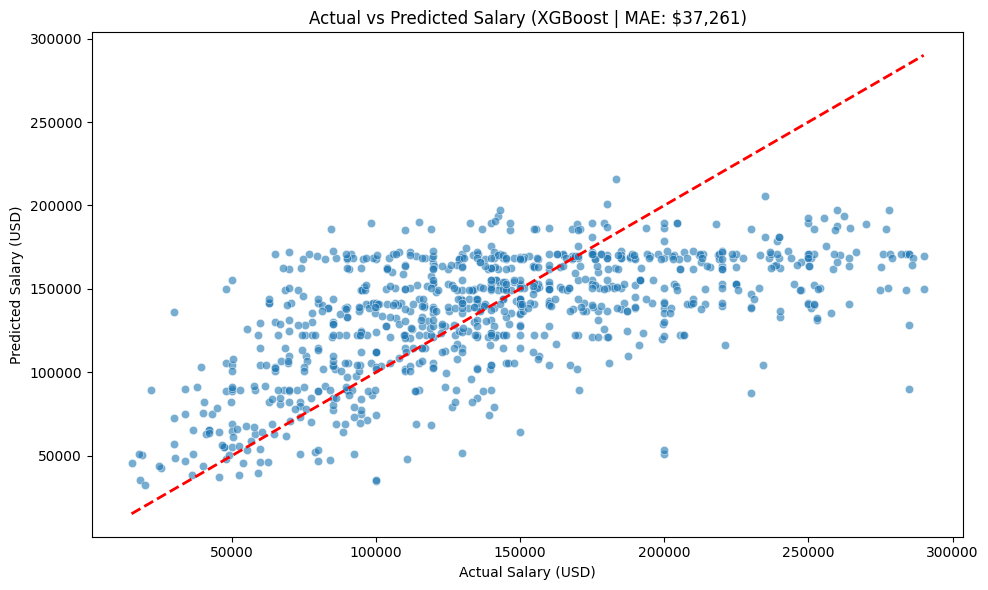


--- 3 SAMPLE RESULTS (ILLUSTRATIVE) ---
   work_year experience_level employment_type                    job_title  \
0       2020               MI              FT                Data Engineer   
1       2023               SE              FL  Machine Learning Researcher   
2       2025               EN              CT                 Data Analyst   

  employee_residence remote_ratio company_size  actual_salary  \
0                 US          100            L         110000   
1                 UA           50            S          50000   
2                 JM            0            M          52531   

   predicted_salary  absolute_error  
0     125163.101562        15163.10  
1      65125.351562        15125.35  
2      38574.339844        13956.66  

MAE  : $14,748.37
RMSE : $14,759.00
R2   : 0.7163


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from scipy import stats




from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score




RANDOM_STATE = 42
DATA_PATH = "FoAI_A2_data_4.6k.csv"




# =========================
# CUSTOM TRANSFORMER: Country Tier Grouper (4 Tiers)
# =========================
class CountryTierGrouper(BaseEstimator, TransformerMixin):
    """
    Groups employee_residence into 4 Tiers based on optimized salary clustering:
    Tier 1 (Elite): US
    Tier 2 (High): CA, AU, CH, IL, IE, NZ
    Tier 3 (Mid): GB, DE, FR, SG, JP, NL, AT, BE, FI, SE, AE
    Tier 4 (Low): All others (India, Eastern Europe, Vietnam, etc.)
    """
    def __init__(self):
        self.tier_1 = {'US'}
        self.tier_2 = {'CA', 'AU', 'CH', 'IL', 'IE', 'NZ'}
        self.tier_3 = {'GB', 'DE', 'FR', 'SG', 'JP', 'NL', 'AT', 'BE', 'FI', 'SE', 'AE'}




    def fit(self, X, y=None):
        return self




    def transform(self, X):
        X_arr = np.array(X).ravel()
       
        def get_tier(country):
            if country in self.tier_1:
                return 'Tier 1'
            elif country in self.tier_2:
                return 'Tier 2'
            elif country in self.tier_3:
                return 'Tier 3'
            else:
                return 'Tier 4'
       
        vectorized_get = np.vectorize(get_tier)
        return vectorized_get(X_arr).reshape(-1, 1)




# =========================
# CUSTOM TRANSFORMER: Job Role Grouper
# =========================
class JobRoleGrouper(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self




    def transform(self, X):
        X_arr = np.array(X).ravel()
       
        def get_role(title):
            t = str(title).lower()
            if any(k in t for k in ["manager", "head", "director", "lead", "principal"]):
                return "Managerial"
            if any(k in t for k in ["machine learning", "ml", "ai", "computer vision", "nlp"]):
                return "ML_AI"
            if any(k in t for k in ["data scientist", "applied scientist", "research scientist", "researcher"]):
                return "Data_Science"
            if any(k in t for k in ["data engineer", "analytics engineer", "etl"]):
                return "Data_Engineering"
            if any(k in t for k in ["software engineer", "architect", "platform", "cloud", "site reliability", "engineer"]):
                return "Engineering"
            if any(k in t for k in ["data analyst", "product analyst", "business analyst", "bi", "analyst"]):
                return "Data_Analysis"
            return "Other"




        vectorized_get = np.vectorize(get_role)
        return vectorized_get(X_arr).reshape(-1, 1)




# =========================
# DATA LOADING & CLEANING
# =========================
def load_and_clean_data(filepath, outcome_col="salary_in_usd"):
    df = pd.read_csv(filepath)




    # 1. Remove Outliers (Z-score method)
    z_scores = np.abs(stats.zscore(df[outcome_col]))
    df = df[z_scores <= 2].copy()




    # 2. Drop 'company_location' (Highly correlated with employee_residence)
    if 'company_location' in df.columns:
        df = df.drop(columns=['company_location'])




    # Ensure remote_ratio is treated as categorical string
    df["remote_ratio"] = df["remote_ratio"].astype(str)




    print(f"Cleaned dataset shape: {df.shape}")
    return df




# =========================
# PREPROCESSOR
# =========================
def get_preprocessor():
    role_pipeline = Pipeline([
        ('grouper', JobRoleGrouper()),
        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])
   
    tier_pipeline = Pipeline([
        ('grouper', CountryTierGrouper()),
        ('encoder', OrdinalEncoder(categories=[['Tier 4', 'Tier 3', 'Tier 2', 'Tier 1']]))
    ])




    nominal_cols = ["employment_type", "work_year", "remote_ratio"]
    ordinal_cols = ["experience_level", "company_size"]
    ordinal_cats = [["EN", "MI", "SE", "EX"], ["S", "M", "L"]]




    return ColumnTransformer([
        ("role_pipe", role_pipeline, ["job_title"]),
        ("tier_pipe", tier_pipeline, ["employee_residence"]),
        ("nom", OneHotEncoder(handle_unknown="ignore", sparse_output=False), nominal_cols),
        ("ord", OrdinalEncoder(categories=ordinal_cats), ordinal_cols)
    ])




# =========================
# MODEL PIPELINE
# =========================
def build_model_pipeline(preprocessor):
    model = xgb.XGBRegressor(
        objective="reg:absoluteerror",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )




    return Pipeline([
        ("preprocessor", preprocessor),
        ("model", TransformedTargetRegressor(
            regressor=model,
            func=np.log1p,
            inverse_func=np.expm1
        ))
    ])




# =========================
# TRAINING & TUNING
# =========================
def train_and_tune(X_train, y_train, pipeline):
    param_dist = {
        "model__regressor__n_estimators": [200, 400, 600],
        "model__regressor__learning_rate": [0.01, 0.05, 0.1],
        "model__regressor__max_depth": [3, 5, 7],
        "model__regressor__subsample": [0.7, 0.8, 0.9],
        "model__regressor__colsample_bytree": [0.7, 0.8, 0.9]
    }




    search = RandomizedSearchCV(
        pipeline,
        param_distributions=param_dist,
        n_iter=15,
        scoring="neg_mean_absolute_error",
        cv=5,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=1
    )




    search.fit(X_train, y_train)
    return search.best_estimator_




# =========================
# TEST SET EVALUATION (INCLUDES RMSE)
# =========================
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)




    mae = mean_absolute_error(y_test, y_pred)
    # Tính toán RMSE
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)




    print("\n--- TEST SET EVALUATION (4 TIERS) ---")
    print(f"MAE   : ${mae:,.2f}")
    print(f"RMSE  : ${rmse:,.2f}")  # Hiển thị RMSE
    print(f"R2    : {r2:.4f}")


    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
    min_val, max_val = y_test.min(), y_test.max()
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)
    plt.xlabel('Actual Salary (USD)')
    plt.ylabel('Predicted Salary (USD)')
    plt.title(f'Actual vs Predicted Salary (XGBoost | MAE: ${mae:,.0f})')
    plt.tight_layout()
    plt.show()




# =========================
# 3-SAMPLE EVALUATION
# =========================
def evaluate_custom_samples(model):
    samples = pd.DataFrame([
        {
            "work_year": 2020,
            "experience_level": "MI",
            "employment_type": "FT",
            "job_title": "Data Engineer",
            "employee_residence": "US",
            "remote_ratio": "100",
            "company_size": "L",
            "salary_in_usd": 110000
        },
        {
            "work_year": 2023,
            "experience_level": "SE",
            "employment_type": "FL",
            "job_title": "Machine Learning Researcher",
            "employee_residence": "UA",
            "remote_ratio": "50",
            "company_size": "S",
            "salary_in_usd": 50000
        },
        {
            "work_year": 2025,
            "experience_level": "EN",
            "employment_type": "CT",
            "job_title": "Data Analyst",
            "employee_residence": "JM",
            "remote_ratio": "0",
            "company_size": "M",
            "salary_in_usd": 52531
        }
    ])


    X_custom = samples.drop(columns="salary_in_usd")
    y_true = samples["salary_in_usd"]


    y_pred = model.predict(X_custom)


    results = X_custom.copy()
    results["actual_salary"] = y_true.values
    results["predicted_salary"] = y_pred.round(2)
    results["absolute_error"] = np.abs(y_true - y_pred).round(2)


    print("\n--- 3 SAMPLE RESULTS (ILLUSTRATIVE) ---")
    print(results)


    print(f"\nMAE  : ${mean_absolute_error(y_true, y_pred):,.2f}")
    print(f"RMSE : ${np.sqrt(mean_squared_error(y_true, y_pred)):,.2f}")
    print(f"R2   : {r2_score(y_true, y_pred):.4f}")


   


# =========================
# MAIN EXECUTION
# =========================
if __name__ == "__main__":




    df = load_and_clean_data(DATA_PATH)




    X = df.drop(columns=["salary", "salary_currency", "salary_in_usd"], errors="ignore")
    y = df["salary_in_usd"]




    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_STATE
    )




    pipeline = build_model_pipeline(get_preprocessor())
   
    print("Starting training with 4-Tier Country Grouping...")
    best_model = train_and_tune(X_train, y_train, pipeline)




    print("\nBest Parameters found:")
    print(best_model.named_steps['model'].regressor.get_params())
   
    evaluate_model(best_model, X_test, y_test)
    evaluate_custom_samples(best_model)
